<a href="https://colab.research.google.com/github/krishal77/Data_Science/blob/main/lab_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

np.random.seed(42)
X_simple=np.random.rand(100, 1) * 10
y_simple = 3 * X_simple + 7 + np.random.randn(100, 1) * 2

X_train,X_test, y_train,y_test= train_test_split(X_simple, y_simple, test_size=0.2, random_state=42)

simple_lr=LinearRegression()
simple_lr.fit(X_train,y_train)

y_pred_simple=simple_lr.predict(X_test)

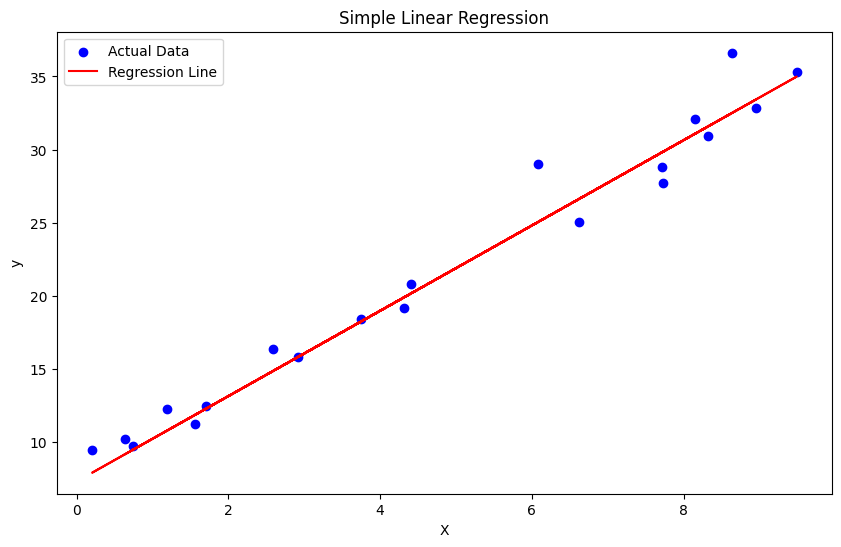

In [3]:
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, color='blue', label='Actual Data')
plt.plot(X_test, y_pred_simple, color='red', label='Regression Line')
plt.title('Simple Linear Regression')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

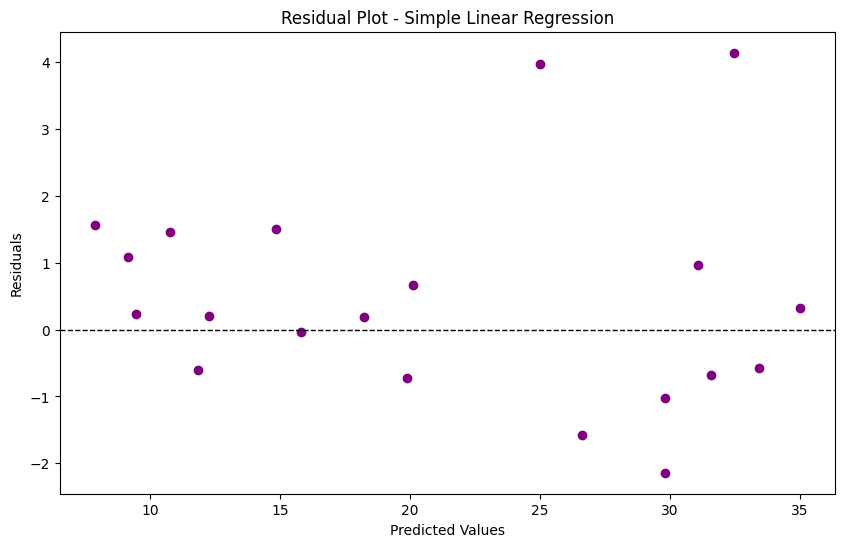

In [4]:
residuals_simple = y_test - y_pred_simple
plt.figure(figsize=(10, 6))
plt.scatter(y_pred_simple, residuals_simple, color='purple')
plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
plt.title('Residual Plot - Simple Linear Regression')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.show()

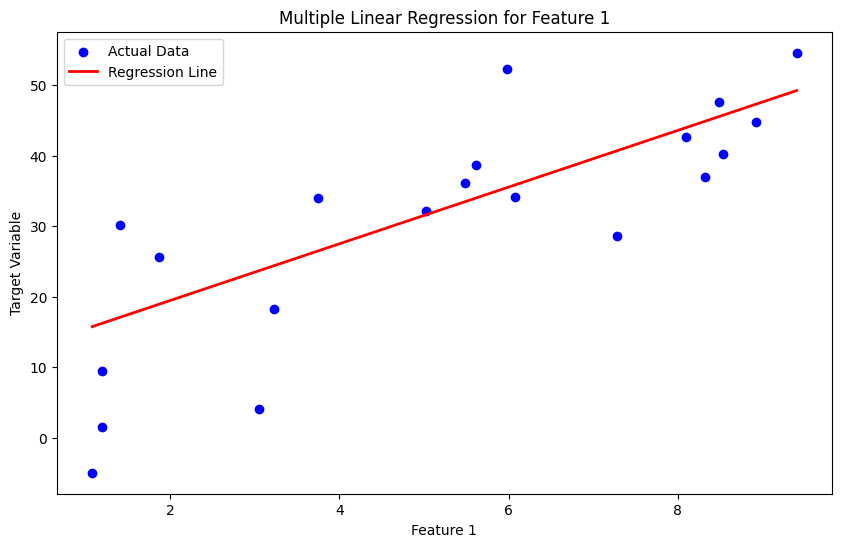

In [8]:
np.random.seed(42)
X_multi = np.random.rand(100, 3) * 10
y_multi = 4 * X_multi[:, 0] + 3 * X_multi[:, 1] - 2 * X_multi[:, 2] + 5 + np.random.randn(100)*2

X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(X_multi,y_multi, test_size=0.2, random_state=42)

multi_lr =LinearRegression()
multi_lr.fit(X_train_multi, y_train_multi)
y_pred_multi= multi_lr.predict(X_test_multi)

## Choose one feature to visualize
feature_index = 0

# Fix other features at their mean values
fixed_features = np.mean(X_test_multi, axis=0)

# Generate values for the selected feature
x_values = np.linspace(
    X_test_multi[:, feature_index].min(),
    X_test_multi[:, feature_index].max(),
    100
)

# Create input data for prediction
X_plot = np.tile(fixed_features, (x_values.shape[0], 1))

# Replace selected feature with varying values
X_plot[:, feature_index] = x_values

# Predict target values
y_plot = multi_lr.predict(X_plot)

# Plot actual test data
plt.figure(figsize=(10, 6))

plt.scatter(
    X_test_multi[:, feature_index],
    y_test_multi,
    color='blue',
    label='Actual Data'
)

# Plot regression line
plt.plot(
    x_values,
    y_plot,
    color='red',
    linewidth=2,
    label='Regression Line'
)

# Labels and title
plt.title(f'Multiple Linear Regression for Feature {feature_index + 1}')
plt.xlabel(f'Feature {feature_index + 1}')
plt.ylabel('Target Variable')

plt.legend()
plt.show()

In [9]:
print("simple linear regression metrices:")
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred_simple):.2f}")
print(f"R2 Score: {r2_score(y_test, y_pred_simple):.2f}\n")
print("Multiple Linear Regression Metrics:")
print(f"Mean Squared Error: {mean_squared_error(y_test_multi, y_pred_multi):.2f}")
print(f"R2 Score: {r2_score(y_test_multi, y_pred_multi):.2f}")

simple linear regression metrices:
Mean Squared Error: 2.61
R2 Score: 0.97

Multiple Linear Regression Metrics:
Mean Squared Error: 8.07
R2 Score: 0.97
